In [1]:
import numpy as np 
import pandas as pd

In [2]:
base_path = "../data_corr_0.33_negative_10000_knn/"

In [3]:
nedbit_path = "df_nebit_dnam_features_bc_PNA.csv"
df_nebit_features = pd.read_csv(base_path + nedbit_path, sep=",")
df_nebit_features

,name,degree,ring,NetRank,NetShort,HeatDiff,InfoDiff,0,1,2,...,71,72,73,74,75,76,77,78,79,labels
0,cg15694422_MGLL,1810,1,0.854886,752.42470,1.063538e+00,0.019724,0.420649,0.315654,0.371301,...,0.304428,0.370463,0.571908,0.439803,0.560614,0.483471,0.521094,0.464730,0.438450,1
1,cg26582754_PHACTR2,2204,1,0.886517,705.30360,8.349054e-01,0.019747,0.413432,0.359373,0.298765,...,0.389566,0.494176,0.504004,0.452477,0.496821,0.488674,0.407097,0.511305,0.369165,1
2,cg23061704_ALDH1A1,2566,2,1.997556,516.11150,8.707579e-03,0.019449,0.589507,0.693797,0.595770,...,0.532390,0.636823,0.683208,0.747087,0.701678,0.687001,0.629427,0.654190,0.560457,3
3,cg06274263_TMEM52B,2168,2,1.997557,514.10950,8.029710e-03,0.019525,0.474480,0.456571,0.400066,...,0.373927,0.579147,0.506782,0.570009,0.544366,0.474520,0.486283,0.556706,0.434329,3
4,cg00883212_RAPGEF4,2718,2,1.997521,520.63910,5.964529e-03,0.019072,0.784545,0.893411,0.851342,...,0.867931,0.908722,0.811370,0.884263,0.893509,0.909702,0.829950,0.823561,0.783630,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10192,cg21375582_C10orf11,2,3,2.998849,103.92260,4.559843e-07,0.000088,0.191596,0.078362,0.192389,...,0.105712,0.144717,0.068254,0.148874,0.059930,0.105029,0.042542,0.112401,0.117847,5
10193,cg17088462_GSTO1,1,3,2.991143,104.25250,1.149006e-06,0.000079,0.137779,0.077199,0.166958,...,0.061650,0.082304,0.059932,0.021833,0.074133,0.065522,0.025311,0.131405,0.069257,5
10194,cg21899558_PRKAR1B,1,3,2.996486,103.15290,1.128693e-05,0.000048,0.870114,0.870820,0.927680,...,0.763295,0.725618,0.717641,0.821020,0.959873,0.951837,0.782169,0.828560,0.780971,5
10195,cg09975865_TEC,4,3,2.988275,115.36460,2.082064e-04,0.000147,0.981974,0.962446,0.972452,...,0.972368,0.969658,0.967920,0.956431,0.984143,0.975954,0.969484,0.981684,0.975025,5


In [4]:
df_degree_labels = df_nebit_features[["degree", "labels"]]
df_degree_labels

,degree,labels
0,1810,1
1,2204,1
2,2566,3
3,2168,3
4,2718,2
...,...,...
10192,2,5
10193,1,5
10194,1,5
10195,4,5


{1: 372559, 3: 6893769, 2: 7646816, 4: 4669690, 5: 244068}


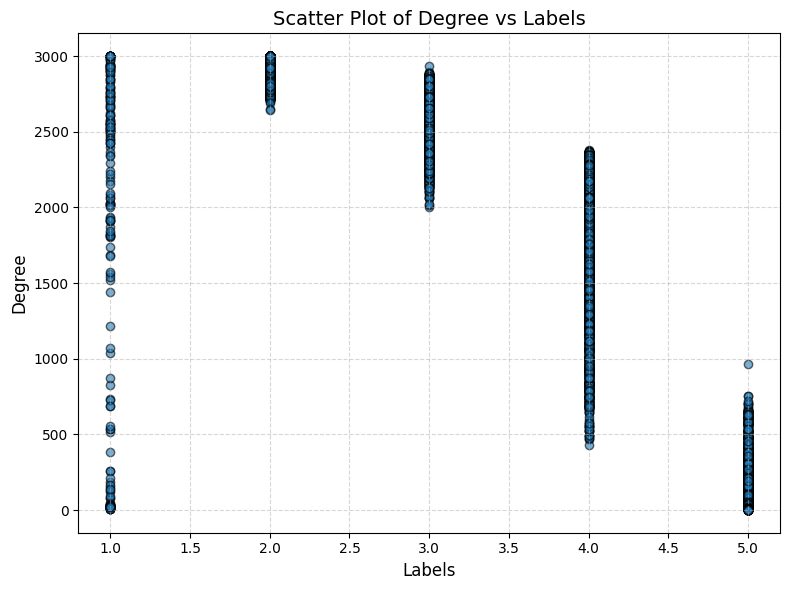

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'degree': df_degree_labels["degree"].tolist(),
    'labels': df_degree_labels["labels"].tolist(),
}
df = pd.DataFrame(data)

agg_dict = {}

for index, row in df.iterrows():
    if row["labels"] not in agg_dict:
        agg_dict[row["labels"]] = int(row["degree"])
    else:
        agg_dict[row["labels"]] += row["degree"]

print(agg_dict)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['labels'], df['degree'], alpha=0.6, edgecolor='k')

# Add labels and title
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Degree", fontsize=12)
plt.title("Scatter Plot of Degree vs Labels", fontsize=14)

# Optional: grid and styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show plot
plt.show()

       degree  labels
0        1810       1
1        2204       1
2        2566       3
3        2168       3
4        2718       2
...       ...     ...
10192       2       5
10193       1       5
10194       1       5
10195       4       5
10196       1       5

[10197 rows x 2 columns]
   labels         mean  median
0       1  1891.162437  2428.0
1       2  2881.241899  2876.0
2       3  2597.501507  2640.5
3       4  1760.154542  1882.0
4       5   119.699853    39.0


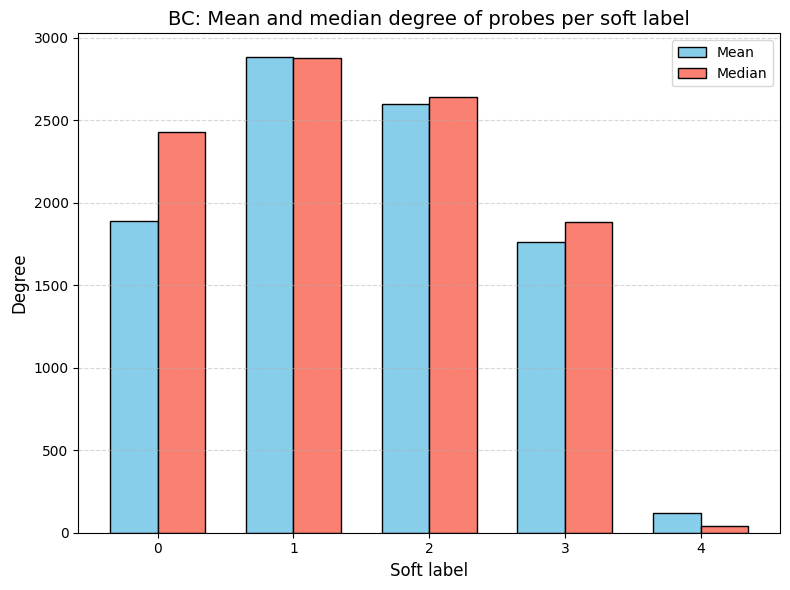

In [8]:
# Example: load data (adjust path as needed)
# df = pd.read_csv("data.csv", sep="\t")  # if tab-separated
# or if it's already in memory:
data = {
    'degree': df_degree_labels["degree"].tolist(),
    'labels': df_degree_labels["labels"].tolist(),
}
df = pd.DataFrame(data)

print(df)

grouped = df.groupby('labels')['degree'].agg(['mean', 'median']).reset_index()

print(grouped)

# --- Plot ---
plt.figure(figsize=(8, 6))

# Plot mean and median as grouped bars
width = 0.35
x = range(len(grouped))

plt.bar([i - width/2 for i in x], grouped['mean'], width=width, label='Mean', color='skyblue', edgecolor='k')
plt.bar([i + width/2 for i in x], grouped['median'], width=width, label='Median', color='salmon', edgecolor='k')

# --- Labels and styling ---
plt.xticks(x, grouped['labels'] - 1)
plt.xlabel('Soft label', fontsize=12)
plt.ylabel('Degree', fontsize=12)
plt.title('BC: Mean and median degree of probes per soft label', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("degree_per_soft_label_bc.pdf", dpi=300)  # Save the figure
plt.show()

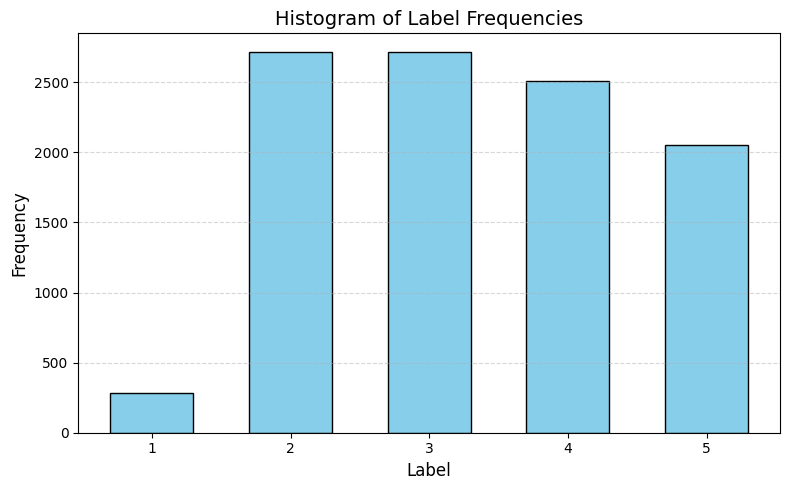

In [7]:
# Example: load data (adjust path as needed)
# df = pd.read_csv("data.csv", sep="\t")  # if tab-separated
# or if it's already in memory:
data = {
    'degree': df_degree_labels["degree"].tolist(),
    'labels': df_degree_labels["labels"].tolist(),
}
df = pd.DataFrame(data)

# --- Compute frequency of each label ---
label_counts = df['labels'].value_counts().sort_index()

# --- Plot histogram / bar plot ---
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values, color='skyblue', edgecolor='black', width=0.6)

# --- Labels and formatting ---
plt.xlabel("Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of Label Frequencies", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
